# Grouped Query Attention (GQA) Experiments

This notebook trains and evaluates a Transformer with **Grouped Query Attention (GQA)** on a synthetic in-context linear regression task.

We compare the model against:
- **LSA**: closed-form least squares solution (oracle baseline)
- **GD**: gradient descent solver baseline

Outputs are saved to: `results/gqa/`

In [39]:
import os, math, time, random, json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

os.makedirs("results/gqa", exist_ok=True)

Device: cpu


In [40]:
#config 

cfg = {
    "d_in": 10,
    "noise": 0.0,
    "n_context": 10,
    
    "batch_size": 156,
    "steps": 1000,
    "eval_every": 200,
    "lr": 3e-4,
    "weight_decay": 0.0,

    "d_model": 128,
    "n_heads": 8,
    "n_kv_heads": 2,   # GQA knob
    "dropout": 0.0,

    "gd_steps": 50,
    "gd_lr": 0.1,

    "eval_batches": 30, 

    "num_layers_list": [1, 2, 4],
}

cfg

{'d_in': 10,
 'noise': 0.0,
 'n_context': 10,
 'batch_size': 156,
 'steps': 1000,
 'eval_every': 200,
 'lr': 0.0003,
 'weight_decay': 0.0,
 'd_model': 128,
 'n_heads': 8,
 'n_kv_heads': 2,
 'dropout': 0.0,
 'gd_steps': 50,
 'gd_lr': 0.1,
 'eval_batches': 30,
 'num_layers_list': [1, 2, 4]}

In [41]:
#task generation

def make_batch(B, n_context, d_in, noise=0.0, device="cpu"):
    w_true = torch.randn(B, d_in, 1, device=device)
    Xc = torch.randn(B, n_context, d_in, device=device)
    yc = Xc @ w_true + noise * torch.randn(B, n_context, 1, device=device)

    Xq = torch.randn(B, 1, d_in, device=device)
    yq = Xq @ w_true + noise * torch.randn(B, 1, 1, device=device)
    return w_true, Xc, yc, Xq, yq

In [42]:
#prompt token builder 

def build_tokens(Xc, yc, Xq):
    B, k, d = Xc.shape
    ctx_tokens = torch.cat([Xc, yc], dim=-1)  # [B, k, d+1]
    q_token = torch.cat([Xq, torch.zeros(B, 1, 1, device=Xc.device)], dim=-1)  # [B,1,d+1]
    tokens = torch.cat([ctx_tokens, q_token], dim=1)  # [B, k+1, d+1]
    return tokens

In [43]:
#Baselines: LSA and GD

def least_squares_solution(Xc, yc):
    Xt = Xc.transpose(1, 2)             
    XtX = Xt @ Xc                       
    XtX_pinv = torch.linalg.pinv(XtX)  
    w_hat = XtX_pinv @ Xt @ yc          
    return w_hat

def gd_solution(Xc, yc, steps=50, lr=0.1):
    B, k, d = Xc.shape
    w = torch.zeros(B, d, 1, device=Xc.device, requires_grad=True)
    opt = torch.optim.SGD([w], lr=lr)

    for _ in range(steps):
        opt.zero_grad()
        pred = Xc @ w
        loss = F.mse_loss(pred, yc)
        loss.backward()
        opt.step()

    return w.detach()

def mse_from_w(Xq, yq, w_hat):
    pred = Xq @ w_hat  # [B,1,1]
    return F.mse_loss(pred, yq).item()

def cosine_sim_w(w_true, w_hat, eps=1e-8):
    a = w_true.squeeze(-1)
    b = w_hat.squeeze(-1)
    a_norm = a / (a.norm(dim=1, keepdim=True) + eps)
    b_norm = b / (b.norm(dim=1, keepdim=True) + eps)
    return (a_norm * b_norm).sum(dim=1).mean().item()


In [44]:
#GQA

In [45]:
class GQAAttention(nn.Module):
    def __init__(self, d_model, n_heads, n_kv_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        assert n_heads % n_kv_heads == 0, "n_heads must be divisible by n_kv_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.head_dim = d_model // n_heads
        self.group_size = n_heads // n_kv_heads

        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, n_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(d_model, n_kv_heads * self.head_dim, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        # x: [B, T, D]
        B, T, D = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)       # [B,H,T,Hd]
        k = self.k_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)    # [B,KV,T,Hd]
        v = self.v_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)    # [B,KV,T,Hd]

        # Expand KV to match Q heads
        k = k.repeat_interleave(self.group_size, dim=1)  # [B,H,T,Hd]
        v = v.repeat_interleave(self.group_size, dim=1)  # [B,H,T,Hd]

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)  # [B,H,T,T]
        attn = torch.softmax(scores, dim=-1)
        attn = self.drop(attn)

        out = attn @ v  # [B,H,T,Hd]
        out = out.transpose(1, 2).contiguous().view(B, T, D)  # [B,T,D]
        return self.out_proj(out)

class Block(nn.Module):
    def __init__(self, d_model, n_heads, n_kv_heads, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = GQAAttention(d_model, n_heads, n_kv_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

class GQATransformer(nn.Module):
    def __init__(self, token_dim, d_model, n_layers, n_heads, n_kv_heads, dropout=0.0):
        super().__init__()
        self.in_proj = nn.Linear(token_dim, d_model)
        self.blocks = nn.ModuleList([
            Block(d_model, n_heads, n_kv_heads, dropout) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.out = nn.Linear(d_model, 1)  # predict y_query

    def forward(self, tokens):
        x = self.in_proj(tokens)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        return self.out(x[:, -1, :])  # last token corresponds to query token


In [46]:
def evaluate(model, cfg, n_batches=30):
    model.eval()

    mse_gqa_list = []
    mse_lsa_list = []
    mse_gd_list = []
    cos_lsa_list = []
    cos_gd_list = []

    gd_batches = []

    with torch.no_grad():
        for _ in range(n_batches):
            w_true, Xc, yc, Xq, yq = make_batch(
                cfg["batch_size"], cfg["n_context"], cfg["d_in"],
                noise=cfg["noise"], device=DEVICE
            )

            # Model
            tokens = build_tokens(Xc, yc, Xq)
            pred = model(tokens)
            target = yq.squeeze(1)
            mse_gqa_list.append(F.mse_loss(pred, target).item())

            # LSA
            w_lsa = least_squares_solution(Xc, yc)
            mse_lsa_list.append(mse_from_w(Xq, yq, w_lsa))
            cos_lsa_list.append(cosine_sim_w(w_true, w_lsa))

            gd_batches.append((
                w_true.detach(), Xc.detach(), yc.detach(), Xq.detach(), yq.detach()
            ))

    for (w_true, Xc, yc, Xq, yq) in gd_batches:
        w_gd = gd_solution(Xc, yc, steps=cfg["gd_steps"], lr=cfg["gd_lr"])
        mse_gd_list.append(mse_from_w(Xq, yq, w_gd))
        cos_gd_list.append(cosine_sim_w(w_true, w_gd))

    def mean_std(x):
        return float(np.mean(x)), float(np.std(x))

    mse_gqa_mean, mse_gqa_std = mean_std(mse_gqa_list)
    mse_lsa_mean, mse_lsa_std = mean_std(mse_lsa_list)
    mse_gd_mean,  mse_gd_std  = mean_std(mse_gd_list)

    cos_lsa_mean, cos_lsa_std = mean_std(cos_lsa_list)
    cos_gd_mean,  cos_gd_std  = mean_std(cos_gd_list)

    return {
        "mse_gqa_mean": mse_gqa_mean,
        "mse_gqa_std": mse_gqa_std,
        "mse_lsa_mean": mse_lsa_mean,
        "mse_lsa_std": mse_lsa_std,
        "mse_gd_mean": mse_gd_mean,
        "mse_gd_std": mse_gd_std,
        "cosine_lsa_mean": cos_lsa_mean,
        "cosine_lsa_std": cos_lsa_std,
        "cosine_gd_mean": cos_gd_mean,
        "cosine_gd_std": cos_gd_std,
    }

In [47]:
def train_one(num_layers, cfg):
    token_dim = cfg["d_in"] + 1

    model = GQATransformer(
        token_dim=token_dim,
        d_model=cfg["d_model"],
        n_layers=num_layers,
        n_heads=cfg["n_heads"],
        n_kv_heads=cfg["n_kv_heads"],
        dropout=cfg["dropout"],
    ).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

    train_losses = []
    eval_rows = []

    t0 = time.time()
    for step in range(1, cfg["steps"] + 1):
        model.train()

        _, Xc, yc, Xq, yq = make_batch(
            cfg["batch_size"], cfg["n_context"], cfg["d_in"],
            noise=cfg["noise"], device=DEVICE
        )

        tokens = build_tokens(Xc, yc, Xq)
        target = yq.squeeze(1)

        pred = model(tokens)
        loss = F.mse_loss(pred, target)

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % cfg["eval_every"] == 0:
            train_losses.append(loss.item())

        if step == 1 or step % cfg["eval_every"] == 0:
            metrics = evaluate(model, cfg, n_batches=cfg["eval_batches"])
            row = {"step": step, "num_layers": num_layers, **metrics}
            eval_rows.append(row)
            print(f"[layers={num_layers}] step {step:4d} | "
                  f"gqa={metrics['mse_gqa_mean']:.3f} | "
                  f"lsa={metrics['mse_lsa_mean']:.3f} | "
                  f"gd={metrics['mse_gd_mean']:.3f}")

    elapsed = time.time() - t0
    print(f"[layers={num_layers}] Done in {elapsed:.2f}s")

    return model, train_losses, pd.DataFrame(eval_rows)


In [48]:
all_summaries = []

for L in cfg["num_layers_list"]:
    model, train_losses, eval_df = train_one(L, cfg)

    # Save per-run eval CSV
    csv_path = f"results/gqa/eval_layers_{L}.csv"
    eval_df.to_csv(csv_path, index=False)
    print("Saved:", csv_path)

    final = eval_df.iloc[-1].to_dict()

    summary = {
        "num_layers": int(L),
        "mse_gqa_mean": float(final["mse_gqa_mean"]),
        "mse_gqa_std": float(final["mse_gqa_std"]),
        "mse_lsa_mean": float(final["mse_lsa_mean"]),
        "mse_lsa_std": float(final["mse_lsa_std"]),
        "mse_gd_mean": float(final["mse_gd_mean"]),
        "mse_gd_std": float(final["mse_gd_std"]),
        "cosine_lsa_mean": float(final["cosine_lsa_mean"]),
        "cosine_lsa_std": float(final["cosine_lsa_std"]),
        "cosine_gd_mean": float(final["cosine_gd_mean"]),
        "cosine_gd_std": float(final["cosine_gd_std"]),
        "train_losses": [float(x) for x in train_losses],
    }

    all_summaries.append(summary)

summary_path = "results/gqa/summary.json"
with open(summary_path, "w") as f:
    json.dump(all_summaries, f, indent=2)
print("Saved:", summary_path)

all_summaries[:1]

[layers=1] step    1 | gqa=10.404 | lsa=0.023 | gd=8.947
[layers=1] step  200 | gqa=6.264 | lsa=0.011 | gd=8.840
[layers=1] step  400 | gqa=5.919 | lsa=0.018 | gd=8.999
[layers=1] step  600 | gqa=5.637 | lsa=0.018 | gd=8.694
[layers=1] step  800 | gqa=5.607 | lsa=0.011 | gd=8.883
[layers=1] step 1000 | gqa=5.307 | lsa=0.022 | gd=8.663
[layers=1] Done in 27.59s
Saved: results/gqa/eval_layers_1.csv
[layers=2] step    1 | gqa=10.091 | lsa=0.021 | gd=8.627
[layers=2] step  200 | gqa=6.009 | lsa=0.011 | gd=9.075
[layers=2] step  400 | gqa=4.738 | lsa=0.018 | gd=8.548
[layers=2] step  600 | gqa=4.228 | lsa=0.014 | gd=8.458
[layers=2] step  800 | gqa=4.289 | lsa=0.015 | gd=8.744
[layers=2] step 1000 | gqa=4.026 | lsa=0.014 | gd=9.025
[layers=2] Done in 49.61s
Saved: results/gqa/eval_layers_2.csv
[layers=4] step    1 | gqa=10.619 | lsa=0.014 | gd=8.956
[layers=4] step  200 | gqa=5.249 | lsa=0.014 | gd=8.672
[layers=4] step  400 | gqa=4.176 | lsa=0.007 | gd=9.006
[layers=4] step  600 | gqa=3.48

[{'num_layers': 1,
  'mse_gqa_mean': 5.307233738899231,
  'mse_gqa_std': 0.6224261231120198,
  'mse_lsa_mean': 0.02194664212402131,
  'mse_lsa_std': 0.042740861898203246,
  'mse_gd_mean': 8.663280900319418,
  'mse_gd_std': 1.1658549255811874,
  'cosine_lsa_mean': 0.9989722371101379,
  'cosine_lsa_std': 0.0007442164423283839,
  'cosine_gd_mean': 0.7272053678830465,
  'cosine_gd_std': 0.00842203803798057,
  'train_losses': [7.155704021453857,
   7.16606330871582,
   5.813759803771973,
   4.628651142120361,
   4.743991374969482]}]

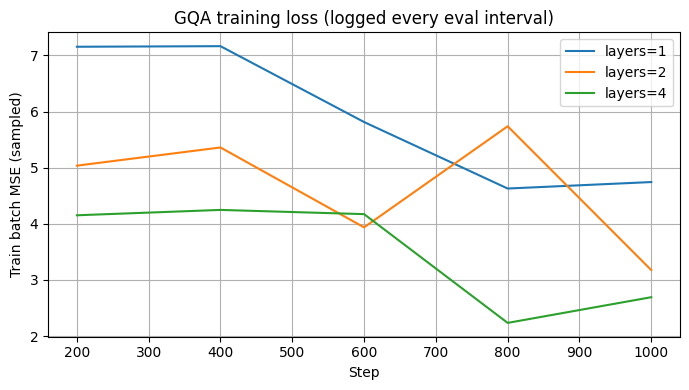

Saved: results/gqa/train_loss_curves.png


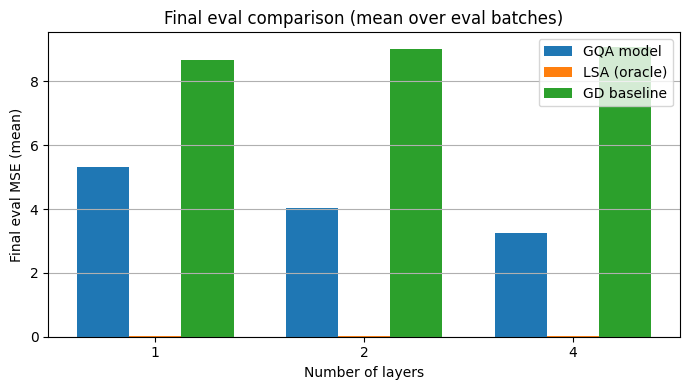

Saved: results/gqa/final_mse_comparison.png


In [49]:
plt.figure(figsize=(7,4))
for s in all_summaries:
    y = s["train_losses"]
    x = np.arange(1, len(y)+1) * cfg["eval_every"]
    plt.plot(x, y, label=f"layers={s['num_layers']}")
plt.xlabel("Step")
plt.ylabel("Train batch MSE (sampled)")
plt.title("GQA training loss (logged every eval interval)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("results/gqa/train_loss_curves.png", dpi=200)
plt.show()
print("Saved: results/gqa/train_loss_curves.png")


layers = [s["num_layers"] for s in all_summaries]
gqa_means = [s["mse_gqa_mean"] for s in all_summaries]
lsa_means = [s["mse_lsa_mean"] for s in all_summaries]
gd_means  = [s["mse_gd_mean"] for s in all_summaries]

x = np.arange(len(layers))
w = 0.25

plt.figure(figsize=(7,4))
plt.bar(x - w, gqa_means, width=w, label="GQA model")
plt.bar(x,      lsa_means, width=w, label="LSA (oracle)")
plt.bar(x + w,  gd_means,  width=w, label="GD baseline")
plt.xticks(x, [str(L) for L in layers])
plt.xlabel("Number of layers")
plt.ylabel("Final eval MSE (mean)")
plt.title("Final eval comparison (mean over eval batches)")
plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()
plt.savefig("results/gqa/final_mse_comparison.png", dpi=200)
plt.show()
print("Saved: results/gqa/final_mse_comparison.png")